In [1]:
#Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Filter the dataset for jobs located in US and create a deep copy to avoid SettingWithCopy warnings
df_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()

# Define a function to unify salary data into a single annual figure
def combine_salaries(row):
    if pd.notna(row['salary_year_avg']):
        return row['salary_year_avg']
    
    # Check for hourly salary and convert to annual (assuming 40 hours/week, 52 weeks/year)
    # NOTE: Changed your 'elif' from 'salary_year_avg' to 'salary_hour_avg' to fix the logic
    elif pd.notna(row['salary_hour_avg']):
        return row['salary_hour_avg'] * 52 * 40
    else:
        return None

# Apply the conversion function across every row (axis=1) to create the new combined salary column
# Note: Use df_US.apply here to ensure you are mapping against the filtered US data
df_US['yearly_salary_combined'] = df_US.apply(combine_salaries, axis=1)
df_US = df_US.dropna(subset='yearly_salary_combined')

In [3]:
job_count = len(df_US)

In [23]:
df_US_skills = df_US.explode('job_skills')
df_US_skills = df_US_skills.groupby('job_skills')['yearly_salary_combined'].agg(['median', 'size'])
df_US_skills = df_US_skills.rename(columns={'median': 'median_salary', 'size': 'skill_count'})
df_US_skills['skill_percent'] = df_US_skills['skill_count']/job_count *100
df_US_skills = df_US_skills.sort_values(by='skill_count', ascending=False)
skill_percent = 5
df_US_skills_in_demand = df_US_skills[df_US_skills['skill_percent'] > skill_percent]
df_US_skills_in_demand

,median_salary,skill_count,skill_percent
job_skills,,,
sql,90000.000000,4361,52.352941
excel,76500.000000,3453,41.452581
tableau,90000.000000,2390,28.691477
python,90000.000000,2303,27.647059
sas,86777.399841,1560,18.727491
power bi,85841.600952,1397,16.770708
r,89000.000000,1338,16.062425
word,70043.500000,868,10.420168
powerpoint,80000.000000,807,9.687875


In [24]:
df_technology = df['job_type_skills'].copy()
df_technology = df_technology.drop_duplicates()
df_technology = df_technology.dropna()

technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])
df_technology = df_technology.explode('skills')
df_technology

,technology,skills
0,analyst_tools,ssis
0,analyst_tools,spreadsheet
0,analyst_tools,powerbi
0,analyst_tools,power bi
0,analyst_tools,looker
...,...,...
9,sync,slack
9,sync,mattermost
9,sync,unify
9,sync,zoom


In [25]:
df_plot = df_US_skills_in_demand.merge(df_technology, left_on='job_skills', right_on='skills')
df_plot

,median_salary,skill_count,skill_percent,technology,skills
0,90000.000000,4361,52.352941,programming,sql
1,76500.000000,3453,41.452581,analyst_tools,excel
2,90000.000000,2390,28.691477,analyst_tools,tableau
3,90000.000000,2303,27.647059,programming,python
4,86777.399841,1560,18.727491,analyst_tools,sas
5,86777.399841,1560,18.727491,programming,sas
6,85841.600952,1397,16.770708,analyst_tools,power bi
7,89000.000000,1338,16.062425,programming,r
8,70043.500000,868,10.420168,analyst_tools,word
9,80000.000000,807,9.687875,analyst_tools,powerpoint


4 [-0.83520203 -0.21429169]
5 [ 0.42851837 -0.734841  ]


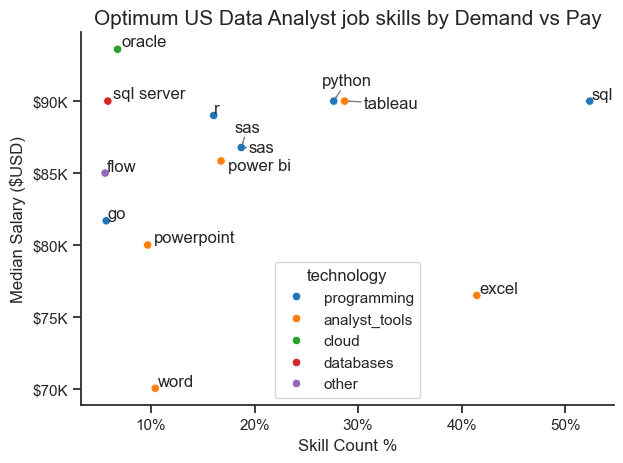

In [27]:
sns.scatterplot(data=df_plot, x='skill_percent', y='median_salary', hue='technology', palette='tab10')
sns.despine()
sns.set_theme(style='ticks')

from adjustText import adjust_text
texts = []
for i, txt in enumerate(df_plot['skills']):
    texts.append(plt.text(df_plot['skill_percent'].iloc[i], df_plot['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops = dict(arrowstyle='->', color='gray'))

from matplotlib.ticker import PercentFormatter
ax= plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlabel('Skill Count %')
plt.ylabel('Median Salary ($USD)')
plt.title('Optimum US Data Analyst job skills by Demand vs Pay', fontsize = 15)
plt.tight_layout()
plt.show()